# «Платформа университетского технологического предпринимательства»

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [3]:
#Веб-страница с таблицей по Республике Башкортостан (2023)
url = 'https://top1000.univertechpred.ru/?regions=1726'

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')
table = soup.find('table')
df = pd.read_html(str(table))[0]

In [4]:
df.head(5)

,#,Итоговый балл,Ф.И.О.,ВУЗ
0,1,96.2,Шадрина Айгюль Эльшадовна,ФГБОУ ВО «Уфимский государственный нефтяной технический университет»
1,NaN,Подготовка и запуск образовательных и профориентационных мероприятий под брендами крупных промышленных предприятий России,Подготовка и запуск образовательных и профориентационных мероприятий под брендами крупных промышленных предприятий России,ФГБОУ ВО «Уфимский государственный нефтяной технический университет»
2,13,82.94,Султанмагомедов Тимур Султанмагомедович,ФГБОУ ВО «Уфимский государственный нефтяной технический университет»
3,NaN,"MechUp — инженерный конструктор, позволяющий визуализировать механические явления","MechUp — инженерный конструктор, позволяющий визуализировать механические явления",ФГБОУ ВО «Уфимский государственный нефтяной технический университет»
4,20,82,Зарипов Шамиль Ришатович,ФГБОУ ВО «Башкирский государственный университет»


In [5]:
#Удаляем строки с NaN
df = df.dropna(subset=['#']).reset_index(drop=True)

df.to_csv('processed_data.csv', index=False)

print(df)

          # Итоговый балл                                   Ф.И.О.  \
0         1          96.2                Шадрина Айгюль Эльшадовна   
1        13         82.94  Султанмагомедов Тимур Султанмагомедович   
2        20            82                 Зарипов Шамиль Ришатович   
3        83         73.74                 Меркушев Антон Сергеевич   
4       107         71.65               Лушников Никита Дмитриевич   
5       133         69.44              Рыжкин Александр Алексеевич   
6   147-148         68.61               Аветисян Гурген Мартикович   
7       158         68.05          Гилязетдинов Руслан Альбертович   
8       244          64.7         Кривоногова Анастасия Евгеньевна   
9   247-248         64.31                 Галимов Дмитрий Олегович   
10  263-264         63.81                    Иванов Олег Сергеевич   
11  266-267         63.71               Максимова Арина Дмитриевна   
12      297         62.44              Иванов Владислав Викторович   
13      304         

In [6]:
df['Итоговый балл'] = pd.to_numeric(df['Итоговый балл'], errors='coerce')
df['Итоговый балл'].mean()

53.02118421052632

## Считаем количество победителей для каждого ВУЗа

In [7]:
vuz_counts = df['ВУЗ'].value_counts().reset_index()
vuz_counts.columns = ['ВУЗ', 'Количество победителей']

vuz_counts

,ВУЗ,Количество победителей
0,ФГБОУ ВО «Уфимский государственный нефтяной технический университет»,29
1,ФГБОУ ВО «Башкирский государственный университет»,14
2,ФГБОУ ВО «Уфимский государственный авиационный технический университет»,12
3,«Институт нефти и газа ФГБОУ ВО «Уфимский государственный нефтяной технический университет» (филиал в г. Октябрьском)»,6
4,«Институт химических технологий и инжиниринга ФГБОУ ВО «Уфимский государственный нефтяной технический университет» (филиал в г. Стерлитамаке)»,5
5,ФГБОУ ВО «Башкирский государственный аграрный университет»,3
6,ФГБОУ ВО «Башкирский государственный медицинский университет» Минздрава России,2
7,ФГБОУ ВО «Башкирский государственный педагогический университет им. М. Акмуллы»,2
8,«Институт нефтепереработки и нефтехимии ФГБОУ ВО «Уфимский государственный нефтяной технический университет» (филиал в г. Салавате)»,1
9,Нефтекамский филиал ФГБОУ ВО «Башкирский государственный университет»,1


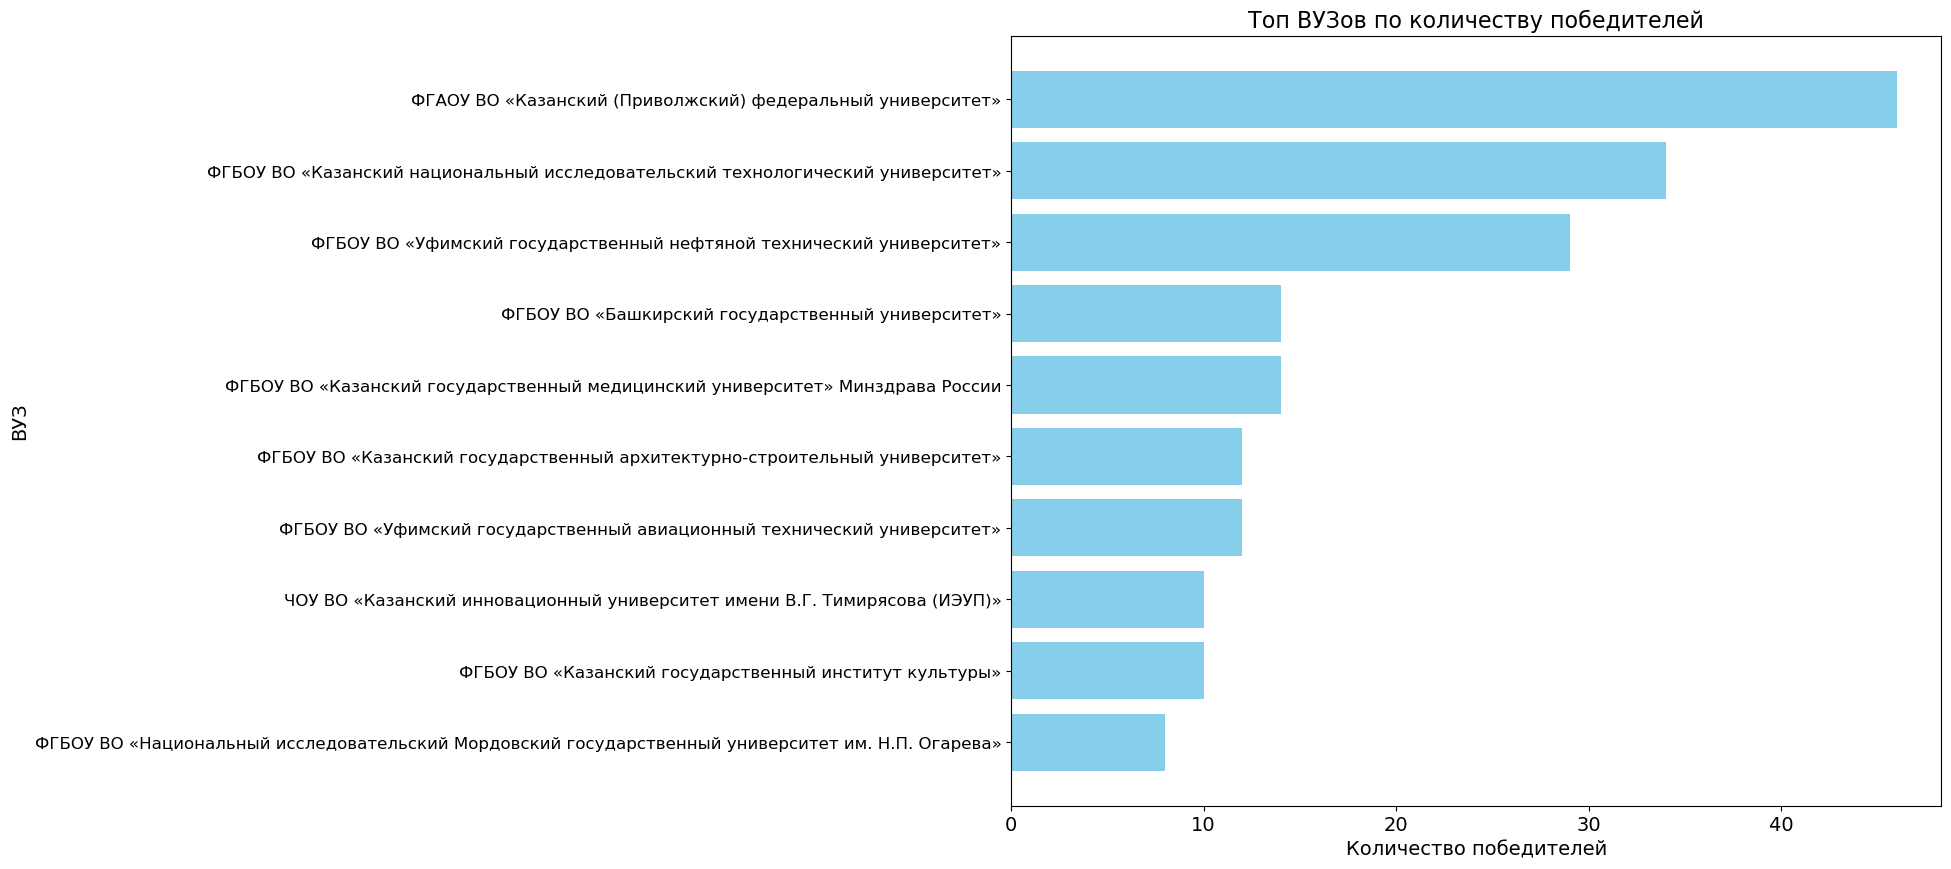

In [24]:
top_vuz_counts = vuz_counts.head(10)

plt.figure(figsize=(12, 10))
plt.barh(top_vuz_counts['ВУЗ'], top_vuz_counts['Количество победителей'], color='skyblue')
plt.xlabel('Количество победителей', fontsize=14)
plt.ylabel('ВУЗ', fontsize=14)
plt.title('Топ ВУЗов по количеству победителей', fontsize=16)
plt.xticks(fontsize=144)
plt.yticks(fontsize=12)
plt.gca().invert_yaxis()
plt.show()

In [9]:
#Веб-страница с таблицей по Республике Башкортостан (2022)
url = 'https://top1000.univertechpred.ru/archive-2022/?regions=1117'

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')
table = soup.find('table')
df2022 = pd.read_html(str(table))[0] 

In [10]:
df2022

,#,Гранто­получатель,ВУЗ,Unnamed: 3
0,49.0,Даутова Элина Руслановна,УГАТУ,NaN
1,NaN,Examium,Examium,Examium
2,53.0,Устинов Александр Витальевич,Стерлитамакский филиал БашГУ,NaN
3,NaN,Разработка технологии и рецептуры напитка на основе какао-веллы,Разработка технологии и рецептуры напитка на основе какао-веллы,Разработка технологии и рецептуры напитка на основе какао-веллы
4,89.0,Кривоногова Анастасия Евгеньевна,УГАТУ,NaN
5,NaN,Интеллектуальная система поиска и анализа цифровой информации,Интеллектуальная система поиска и анализа цифровой информации,Интеллектуальная система поиска и анализа цифровой информации
6,97.0,Султанмагомедов Тимур Султанмагомедович,УГНТУ,NaN
7,NaN,MechUp,MechUp,MechUp
8,147.0,Абдракипова Эльвина Ильшатовна,Башкирский ГАУ,NaN
9,NaN,"Разработка и коммерциализация веб-платформы с ГИС-технологией, позволяющей перевести городские сельскохозяйственные ярмарки в онлайн-формат с доставкой без посредников","Разработка и коммерциализация веб-платформы с ГИС-технологией, позволяющей перевести городские сельскохозяйственные ярмарки в онлайн-формат с доставкой без посредников","Разработка и коммерциализация веб-платформы с ГИС-технологией, позволяющей перевести городские сельскохозяйственные ярмарки в онлайн-формат с доставкой без посредников"


In [11]:
df2022 = df2022.dropna(subset=['#']).reset_index(drop=True)

df2022.to_csv('processed_data.csv', index=False)

print(df2022)

        #                        Гранто­получатель  \
0    49.0                 Даутова Элина Руслановна   
1    53.0             Устинов Александр Витальевич   
2    89.0         Кривоногова Анастасия Евгеньевна   
3    97.0  Султанмагомедов Тимур Султанмагомедович   
4   147.0           Абдракипова Эльвина Ильшатовна   
5   151.0             Шамсутдинова Алия Руслановна   
6   164.0                   Ланцев Илья Леонидович   
7   176.0                   Сладков Роман Игоревич   
8   185.0                  Шарипов Артём Разилевич   
9   197.0                   Бикбов Тимур Радикович   
10  282.0               Мустафин Ильхан Альфирович   
11  286.0           Фаткуллина Назгуль Байтулловна   
12  301.0                 Туктарова Алина Наиловна   
13  310.0                   Малюшин Данил Игоревич   
14  313.0               Лушников Никита Дмитриевич   
15  319.0               Соловьев Богдан Алексеевич   
16  380.0                 Бодылев Андрей Сергеевич   
17  382.0                  К

In [12]:
vuz_counts2022 = df2022['ВУЗ'].value_counts().reset_index()
vuz_counts2022.columns = ['ВУЗ', 'Количество победителей']

vuz_counts2022

,ВУЗ,Количество победителей
0,УГНТУ,15
1,БашГУ,10
2,УГАТУ,8
3,Стерлитамакский филиал БашГУ,6
4,Башкирский ГАУ,3
5,БГМУ,1
6,БАГСУ,1
7,БГПУ им. М. Акмуллы,1
8,Институт нефти и газа ФГБОУ ВО «УГНТУ» в г. Октябрьском,1


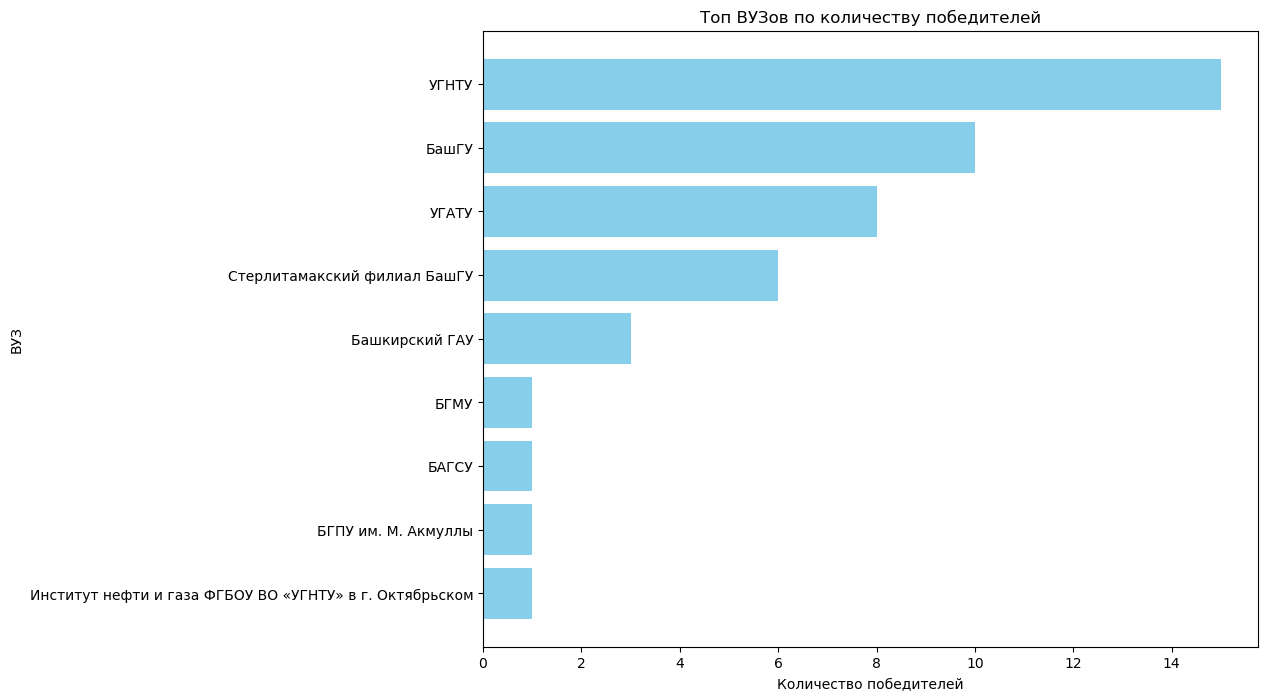

In [13]:
#Визуализация
plt.figure(figsize=(10, 8))
plt.barh(vuz_counts2022['ВУЗ'], vuz_counts2022['Количество победителей'], color='skyblue')
plt.xlabel('Количество победителей')
plt.ylabel('ВУЗ')
plt.title('Топ ВУЗов по количеству победителей')
plt.gca().invert_yaxis()
plt.show()

In [14]:
#Функция с рейтингом всех субъектов ПФО
def extract_table_from_url(url):
    response = requests.get(url)
    
    soup = BeautifulSoup(response.text, 'html.parser')
    
    table = soup.find('table')
    
    df = pd.read_html(str(table))[0]
    
    return df

urls = [
    'https://top1000.univertechpred.ru/?regions=1713,1717,1719,1726,1737,1739,1743,1749,1751,1762,1763,1768',
    'https://top1000.univertechpred.ru/?regions=1713,1717,1719,1726,1737,1739,1743,1749,1751,1762,1763,1768&page=2',
    'https://top1000.univertechpred.ru/?regions=1713,1717,1719,1726,1737,1739,1743,1749,1751,1762,1763,1768&page=3',
    'https://top1000.univertechpred.ru/?regions=1713,1717,1719,1726,1737,1739,1743,1749,1751,1762,1763,1768&page=4'
]

combined_df = pd.DataFrame()

for url in urls:
    df = extract_table_from_url(url)
    combined_df = pd.concat([combined_df, df], ignore_index=True)

print(combined_df.head())

     #  \
0    1   
1  NaN   
2   12   
3  NaN   
4   13   

                                                                                                               Итоговый балл  \
0                                                                                                                       96.2   
1  Подготовка и запуск образовательных и профориентационных мероприятий под брендами крупных промышленных предприятий России   
2                                                                                                                      84.09   
3                                                                          Автоматизированная система измерения биоимпеданса   
4                                                                                                                      82.94   

                                                                                                                      Ф.И.О.  \
0                                         

In [15]:
combined_df = combined_df.dropna(subset=['#']).reset_index(drop=True)

print(combined_df)

           # Итоговый балл                                   Ф.И.О.  \
0          1          96.2                Шадрина Айгюль Эльшадовна   
1         12         84.09            Антипенко Владимир Викторович   
2         13         82.94  Султанмагомедов Тимур Султанмагомедович   
3         20            82                 Зарипов Шамиль Ришатович   
4         22         81.95           Ермилычев Александр Валерьевич   
5         23         81.92                  Ялеев Ильсур Ильнурович   
6         26         81.69         Колиниченко Александр Васильевич   
7         44         78.61               Шуклина Наталья Николаевна   
8         47         78.26                   Салихов Булат Фаилевич   
9         51         77.59                Воропаев Виктор Сергеевич   
10        54         77.38               Сотников Виктор Георгиевич   
11        57         76.47              Власова Маргарита Андреевна   
12     62-63         75.76                  Валиев Динар Зиннурович   
13    

In [28]:
vuz_counts = combined_df['ВУЗ'].value_counts().reset_index()
vuz_counts.columns = ['ВУЗ', 'Количество победителей']

vuz_counts.head(10)

,ВУЗ,Количество победителей
0,ФГАОУ ВО «Казанский (Приволжский) федеральный университет»,46
1,ФГБОУ ВО «Казанский национальный исследовательский технологический университет»,34
2,ФГБОУ ВО «Уфимский государственный нефтяной технический университет»,29
3,ФГБОУ ВО «Башкирский государственный университет»,14
4,ФГБОУ ВО «Казанский государственный медицинский университет» Минздрава России,14
5,ФГБОУ ВО «Казанский государственный архитектурно-строительный университет»,12
6,ФГБОУ ВО «Уфимский государственный авиационный технический университет»,12
7,ЧОУ ВО «Казанский инновационный университет имени В.Г. Тимирясова (ИЭУП)»,10
8,ФГБОУ ВО «Казанский государственный институт культуры»,10
9,ФГБОУ ВО «Национальный исследовательский Мордовский государственный университет им. Н.П. Огарева»,8


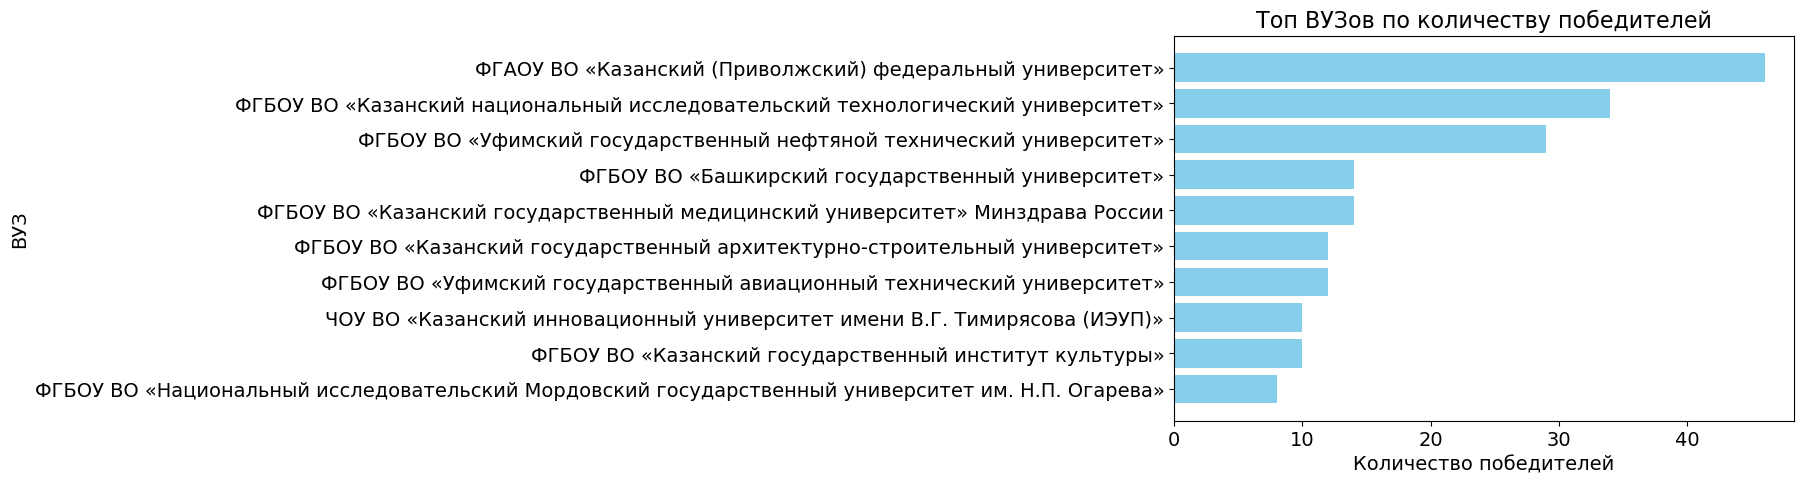

In [27]:
vuz_counts = combined_df['ВУЗ'].value_counts().reset_index()
vuz_counts.columns = ['ВУЗ', 'Количество победителей']

top_vuz_counts = vuz_counts.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_vuz_counts['ВУЗ'], top_vuz_counts['Количество победителей'], color='skyblue')
plt.xlabel('Количество победителей', fontsize=14)
plt.ylabel('ВУЗ', fontsize=14)
plt.title('Топ ВУЗов по количеству победителей', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gca().invert_yaxis()
plt.show()

In [29]:
# Посчитаем "Итоговый балл" в среднем
combined_df['Итоговый балл'] = pd.to_numeric(combined_df['Итоговый балл'], errors='coerce')

average_scores = combined_df.groupby('ВУЗ')['Итоговый балл'].mean().reset_index()
average_scores.columns = ['ВУЗ', 'Средний Итоговый Балл']

average_scores = average_scores.sort_values(by='Средний Итоговый Балл', ascending=False)
average_scores['Место'] = average_scores['Средний Итоговый Балл'].rank(method='dense', ascending=False).astype(int)

average_scores = average_scores[['Место', 'ВУЗ', 'Средний Итоговый Балл']]
average_scores.head(10)

,Место,ВУЗ,Средний Итоговый Балл
16,1,ФГАОУ ВО «Национальный исследовательский Нижегородский государственный университет им. Н.И. Лобачевского»,72.893333
23,2,ФГБОУ ВО «Ижевский государственный технический университет имени М.Т. Калашникова»,69.410000
41,3,"ФГБОУ ВО «Поволжский государственный университет физической культуры, спорта и туризма»",68.350000
11,4,Нижегородский филиал ФГАОУ ВО «Национальный исследовательский университет «Высшая школа экономики»,66.870000
39,5,ФГБОУ ВО «Пензенский государственный университет»,65.068000
34,6,ФГБОУ ВО «Нижегородский государственный архитектурно-строительный университет»,64.250000
17,7,ФГАОУ ВО «Самарский национальный исследовательский университет имени академика С.П. Королева»,63.970000
30,8,ФГБОУ ВО «Казанский национальный исследовательский технический университет им. А.Н. Туполева-КАИ»,62.240000
28,9,ФГБОУ ВО «Казанский государственный медицинский университет» Минздрава России,62.225000
37,10,ФГБОУ ВО «Пензенский государственный технологический университет»,62.040000
